# Urban Livability EDA Report (Indian Cities)

## 1. Setup: Imports, Display Options, and Reproducibility

In [ ]:
import warnings
import re
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

warnings.filterwarnings("ignore")
np.random.seed(42)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 200)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)

DATA_DIR = Path.cwd()
OUTPUT_DIR = DATA_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Working directory: {DATA_DIR}")
print(f"Output directory : {OUTPUT_DIR}")

Working directory: /content
Output directory : /content/outputs


## 2. Discover and Load All Excel Datasets from Folder

In [ ]:
def clean_key(text: str) -> str:
    text = str(text).strip().lower()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    return re.sub(r"_+", "_", text).strip("_")

excel_files = sorted(list(DATA_DIR.glob("*.xlsx")) + list(DATA_DIR.glob("*.xls")))
if not excel_files:
    raise FileNotFoundError("No Excel files found in the working directory.")

raw_datasets = {}
workbook_log = []

for file_path in excel_files:
    xls = pd.ExcelFile(file_path)
    for sheet in xls.sheet_names:
        key_base = clean_key(file_path.stem)
        sheet_key = clean_key(sheet)
        key = key_base if len(xls.sheet_names) == 1 else f"{key_base}__{sheet_key}"

        df = pd.read_excel(file_path, sheet_name=sheet)
        raw_datasets[key] = df.copy()
        workbook_log.append(
            {
                "file_name": file_path.name,
                "sheet_name": sheet,
                "dataset_key": key,
                "rows": df.shape[0],
                "cols": df.shape[1],
            }
        )

load_log_df = pd.DataFrame(workbook_log).sort_values(["file_name", "sheet_name"]).reset_index(drop=True)
print(f"Loaded datasets: {len(raw_datasets)}")
display(load_log_df)

Loaded datasets: 10


,file_name,sheet_name,dataset_key,rows,cols
0,Cost_of_Living_Dataset.xlsx,City Detailed Data,cost_of_living_dataset,19,4
1,Crime_Dataset.xlsx,Sheet1,crime_dataset,19,5
2,Population_Density_Dataset.xlsx,Population Density,population_density_dataset,19,4
3,Public_Transport_Dataset.xlsx,Sheet1,public_transport_dataset,19,4
4,education_facilities_dataset.xlsx,Education Facilities,education_facilities_dataset,19,5
5,healthcare_facilities_dataset.xlsx,Healthcare Facilities,healthcare_facilities_dataset,19,4
6,pollution_dataset.xlsx,Pollution Dataset,pollution_dataset,19,7
7,sewerage_sanitation_dataset.xlsx,Sewerage Coverage,sewerage_sanitation_dataset,19,5
8,traffic_conditions_dataset.xlsx,Traffic Conditions,traffic_conditions_dataset,19,5
9,water_availability_dataset.xlsx,Sheet1,water_availability_dataset,19,4


## 3. Schema Audit: Column Profiling and Data Quality Snapshot

In [ ]:
CITY_COL_PATTERNS = ["city", "district", "town", "municipality", "location", "urban_area"]

def guess_city_column(df: pd.DataFrame) -> str | None:
    lower_cols = {c: str(c).strip().lower() for c in df.columns}
    for col, lc in lower_cols.items():
        if any(p in lc for p in CITY_COL_PATTERNS):
            return col
    return None

def profile_dataframe(name: str, df: pd.DataFrame) -> dict:
    city_col = guess_city_column(df)
    city_unique = df[city_col].nunique(dropna=True) if city_col else np.nan
    return {
        "dataset": name,
        "rows": len(df),
        "columns": len(df.columns),
        "city_column": city_col,
        "unique_cities": city_unique,
        "duplicate_rows": int(df.duplicated().sum()),
        "missing_cells_pct": round(float(df.isna().mean().mean() * 100), 2),
        "numeric_columns": int(df.select_dtypes(include=np.number).shape[1]),
    }

audit_rows = [profile_dataframe(name, df) for name, df in raw_datasets.items()]
audit_df = pd.DataFrame(audit_rows).sort_values("dataset").reset_index(drop=True)
display(audit_df)

print("\nSample column-level snapshot (first dataset):")
first_key = next(iter(raw_datasets))
first_df = raw_datasets[first_key]
col_snapshot = pd.DataFrame(
    {
        "column": first_df.columns,
        "dtype": first_df.dtypes.astype(str).values,
        "missing_pct": (first_df.isna().mean() * 100).round(2).values,
        "n_unique": [first_df[c].nunique(dropna=True) for c in first_df.columns],
    }
)
print(f"Dataset shown: {first_key}")
display(col_snapshot.head(20))

,dataset,rows,columns,city_column,unique_cities,duplicate_rows,missing_cells_pct,numeric_columns
0,cost_of_living_dataset,19,4,City,19,0,0.0,3
1,crime_dataset,19,5,City,19,0,0.0,4
2,education_facilities_dataset,19,5,City,19,0,0.0,3
3,healthcare_facilities_dataset,19,4,City,19,0,0.0,2
4,pollution_dataset,19,7,City,19,0,0.0,5
5,population_density_dataset,19,4,City,19,0,0.0,2
6,public_transport_dataset,19,4,City,19,0,0.0,3
7,sewerage_sanitation_dataset,19,5,City,19,0,0.0,3
8,traffic_conditions_dataset,19,5,City,19,0,0.0,3
9,water_availability_dataset,19,4,City,19,0,0.0,3



Sample column-level snapshot (first dataset):
Dataset shown: cost_of_living_dataset


,column,dtype,missing_pct,n_unique
0,City,object,0.0,19
1,Avg House Rent (₹),int64,0.0,10
2,Utility Bills (₹),int64,0.0,4
3,Monthly Living Cost (₹),int64,0.0,11


## 4. Clean Missing Values and Drop Over-Incomplete Rows

In [ ]:
def parse_numeric(series: pd.Series) -> pd.Series:
    cleaned = (
        series.astype(str)
        .str.replace(r"[₹,]", "", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.replace(r"[^0-9.\-]", "", regex=True)
        .replace({"": np.nan, "-": np.nan})
    )
    return pd.to_numeric(cleaned, errors="coerce")

def clean_missing_values(df: pd.DataFrame, dataset_name: str, row_missing_threshold: float = 0.6):
    temp = df.copy()
    temp.columns = [str(c).strip() for c in temp.columns]
    temp = temp.replace(r"^\s*$", np.nan, regex=True)

    log_rows = []

    # Convert likely numeric object columns to numeric when safe.
    for col in temp.columns:
        if temp[col].dtype == object:
            numeric_version = parse_numeric(temp[col])
            conversion_ratio = numeric_version.notna().mean()
            if conversion_ratio >= 0.6:
                temp[col] = numeric_version
                log_rows.append({"dataset": dataset_name, "action": "coerce_numeric", "column": col, "detail": f"success_ratio={conversion_ratio:.2f}"})

    # Drop rows that are too incomplete.
    row_missing = temp.isna().mean(axis=1)
    before_rows = len(temp)
    temp = temp.loc[row_missing <= row_missing_threshold].copy()
    dropped = before_rows - len(temp)
    log_rows.append({"dataset": dataset_name, "action": "drop_incomplete_rows", "column": "<row>", "detail": f"dropped={dropped}"})

    # Fill missing values.
    for col in temp.columns:
        if pd.api.types.is_numeric_dtype(temp[col]):
            if temp[col].isna().any():
                med = temp[col].median(skipna=True)
                if pd.isna(med):
                    med = temp[col].mean(skipna=True)
                temp[col] = temp[col].fillna(med)
                log_rows.append({"dataset": dataset_name, "action": "fill_numeric", "column": col, "detail": "median/mean"})
        else:
            if temp[col].isna().any():
                temp[col] = temp[col].ffill()
                if temp[col].isna().any():
                    mode_vals = temp[col].mode(dropna=True)
                    if len(mode_vals) > 0:
                        temp[col] = temp[col].fillna(mode_vals.iloc[0])
                log_rows.append({"dataset": dataset_name, "action": "fill_non_numeric", "column": col, "detail": "forward_fill_then_mode"})

    return temp, log_rows

cleaned_datasets = {}
cleaning_logs = []

for name, df in raw_datasets.items():
    cdf, logs = clean_missing_values(df, name)
    cleaned_datasets[name] = cdf
    cleaning_logs.extend(logs)

cleaning_log_df = pd.DataFrame(cleaning_logs)
print(f"Datasets cleaned: {len(cleaned_datasets)}")
display(cleaning_log_df.head(30))

Datasets cleaned: 10


,dataset,action,column,detail
0,cost_of_living_dataset,drop_incomplete_rows,<row>,dropped=0
1,crime_dataset,drop_incomplete_rows,<row>,dropped=0
2,population_density_dataset,drop_incomplete_rows,<row>,dropped=0
3,public_transport_dataset,drop_incomplete_rows,<row>,dropped=0
4,education_facilities_dataset,drop_incomplete_rows,<row>,dropped=0
5,healthcare_facilities_dataset,drop_incomplete_rows,<row>,dropped=0
6,pollution_dataset,drop_incomplete_rows,<row>,dropped=0
7,sewerage_sanitation_dataset,drop_incomplete_rows,<row>,dropped=0
8,traffic_conditions_dataset,drop_incomplete_rows,<row>,dropped=0
9,water_availability_dataset,drop_incomplete_rows,<row>,dropped=0


## 5. Unit Harmonization and Numeric Type Standardization

In [ ]:
def harmonize_units(df: pd.DataFrame, dataset_name: str):
    temp = df.copy()
    logs = []

    for col in temp.columns:
        col_l = str(col).lower()
        if pd.api.types.is_numeric_dtype(temp[col]):
            pass
        elif temp[col].dtype == object:
            num = parse_numeric(temp[col])
            if num.notna().mean() >= 0.6:
                temp[col] = num

        # Rent: yearly to monthly if indicated.
        if "rent" in col_l and ("year" in col_l or "annual" in col_l):
            temp[col] = pd.to_numeric(temp[col], errors="coerce") / 12.0
            logs.append({"dataset": dataset_name, "column": col, "conversion": "annual_to_monthly_rent"})

        # Population density: per square mile to per square km.
        if "density" in col_l and ("sq mile" in col_l or "square mile" in col_l):
            temp[col] = pd.to_numeric(temp[col], errors="coerce") / 2.58999
            logs.append({"dataset": dataset_name, "column": col, "conversion": "per_sq_mile_to_per_sq_km"})

        # PM values occasionally entered as mg/m3 equivalent scale; if suspiciously tiny, upscale.
        if ("pm2.5" in col_l or "pm10" in col_l) and pd.api.types.is_numeric_dtype(temp[col]):
            col_series = pd.to_numeric(temp[col], errors="coerce")
            if col_series.dropna().median() < 1:
                temp[col] = col_series * 1000
                logs.append({"dataset": dataset_name, "column": col, "conversion": "pm_scaled_to_ug_m3"})

    # Final numeric coercion for mixed columns that are mostly numeric.
    for col in temp.columns:
        if temp[col].dtype == object:
            num = parse_numeric(temp[col])
            if num.notna().mean() >= 0.8:
                temp[col] = num

    return temp, logs

harmonized_datasets = {}
unit_logs = []

for name, df in cleaned_datasets.items():
    hdf, hlogs = harmonize_units(df, name)
    harmonized_datasets[name] = hdf
    unit_logs.extend(hlogs)

unit_log_df = pd.DataFrame(unit_logs)
print(f"Datasets harmonized: {len(harmonized_datasets)}")
if not unit_log_df.empty:
    display(unit_log_df)
else:
    print("No explicit unit conversions were required based on detected column names.")

Datasets harmonized: 10
No explicit unit conversions were required based on detected column names.


## 6. Deduplication and City Name Canonicalization

In [ ]:
CITY_MAP = {
    "new delhi": "Delhi",
    "nct delhi": "Delhi",
    "delhi ncr": "Delhi",
    "bangalore": "Bengaluru",
    "bombay": "Mumbai",
    "calcutta": "Kolkata",
    "madras": "Chennai",
    "gurgaon": "Gurugram",
    "trivandrum": "Thiruvananthapuram",
}

def canonicalize_city_name(x: str) -> str:
    if pd.isna(x):
        return np.nan
    val = str(x).strip().lower()
    val = re.sub(r"\s+", " ", val)
    val = CITY_MAP.get(val, val)
    return val.title()


def guess_period_columns(df: pd.DataFrame) -> list:
    period_keywords = ["year", "month", "quarter", "date", "period"]
    return [c for c in df.columns if any(k in str(c).lower() for k in period_keywords)]


deduped_datasets = {}
dedup_log = []

for name, df in harmonized_datasets.items():
    temp = df.copy()
    city_col = guess_city_column(temp)

    if city_col is None:
        deduped_datasets[name] = temp
        dedup_log.append({"dataset": name, "action": "no_city_column_found", "removed_duplicates": 0})
        continue

    temp[city_col] = temp[city_col].apply(canonicalize_city_name)
    temp = temp.rename(columns={city_col: "city"})
    temp = temp[~temp["city"].isna()].copy()

    subset_cols = ["city"] + guess_period_columns(temp)
    before = len(temp)
    temp = temp.drop_duplicates(subset=subset_cols, keep="last")
    removed = before - len(temp)

    deduped_datasets[name] = temp
    dedup_log.append({"dataset": name, "action": "deduplicated", "removed_duplicates": removed, "city_col": city_col})

dedup_log_df = pd.DataFrame(dedup_log)
display(dedup_log_df)

city_coverage = []
for name, df in deduped_datasets.items():
    city_coverage.append({"dataset": name, "city_count": int(df["city"].nunique()) if "city" in df.columns else np.nan})

display(pd.DataFrame(city_coverage).sort_values("dataset"))

,dataset,action,removed_duplicates,city_col
0,cost_of_living_dataset,deduplicated,0,City
1,crime_dataset,deduplicated,0,City
2,population_density_dataset,deduplicated,0,City
3,public_transport_dataset,deduplicated,0,City
4,education_facilities_dataset,deduplicated,0,City
5,healthcare_facilities_dataset,deduplicated,0,City
6,pollution_dataset,deduplicated,0,City
7,sewerage_sanitation_dataset,deduplicated,0,City
8,traffic_conditions_dataset,deduplicated,0,City
9,water_availability_dataset,deduplicated,0,City


,dataset,city_count
0,cost_of_living_dataset,19
1,crime_dataset,19
4,education_facilities_dataset,19
5,healthcare_facilities_dataset,19
6,pollution_dataset,19
2,population_density_dataset,19
3,public_transport_dataset,19
7,sewerage_sanitation_dataset,19
8,traffic_conditions_dataset,19
9,water_availability_dataset,19


## 7. Define Category Weights, Sub-Parameter Weights, and Metric Direction

In [ ]:
CATEGORY_WEIGHTS = {
    "crime": 0.15,
    "water": 0.12,
    "pollution": 0.10,
    "traffic": 0.10,
    "population": 0.06,
    "sanitation": 0.10,
    "education": 0.10,
    "healthcare": 0.12,
    "cost": 0.10,
    "transport": 0.05,
}

SUBPARAM_CONFIG = {
    "crime": {
        "file_hints": ["crime"],
        "subparams": {
            "theft_cases": {"weight": 0.20, "positive": False, "keywords": ["theft"]},
            "violent_crime_cases": {"weight": 0.35, "positive": False, "keywords": ["violent", "crime"]},
            "women_safety_complaints": {"weight": 0.25, "positive": False, "keywords": ["women", "safety", "complaint"]},
            "crime_per_lakh": {"weight": 0.20, "positive": False, "keywords": ["crime", "lakh"]},
        },
    },
    "water": {
        "file_hints": ["water"],
        "subparams": {
            "groundwater_level": {"weight": 0.35, "positive": True, "keywords": ["groundwater", "ground", "water level"]},
            "water_complaints": {"weight": 0.30, "positive": False, "keywords": ["water", "complaint"]},
            "water_quality": {"weight": 0.35, "positive": True, "keywords": ["water", "quality"]},
        },
    },
    "pollution": {
        "file_hints": ["pollution"],
        "subparams": {
            "aqi": {"weight": 0.40, "positive": False, "keywords": ["aqi", "air quality"]},
            "pm_levels": {"weight": 0.25, "positive": False, "keywords": ["pm2", "pm10", "pm "]},
            "industrial_pollution": {"weight": 0.20, "positive": False, "keywords": ["industrial", "pollution"]},
            "waste_generation": {"weight": 0.15, "positive": False, "keywords": ["waste", "generation"]},
        },
    },
    "traffic": {
        "file_hints": ["traffic"],
        "subparams": {
            "traffic_congestion": {"weight": 0.40, "positive": False, "keywords": ["congestion", "traffic level"]},
            "peak_hour_load": {"weight": 0.30, "positive": False, "keywords": ["peak", "hour", "load"]},
            "road_accidents": {"weight": 0.30, "positive": False, "keywords": ["accident", "crash"]},
        },
    },
    "population": {
        "file_hints": ["population", "density"],
        "subparams": {
            "population_per_sq_km": {"weight": 0.65, "positive": False, "keywords": ["population", "sq", "km", "density"]},
            "urban_crowding": {"weight": 0.35, "positive": False, "keywords": ["urban", "crowding"]},
        },
    },
    "sanitation": {
        "file_hints": ["sewer", "sanitation"],
        "subparams": {
            "sewerage_coverage": {"weight": 0.40, "positive": True, "keywords": ["sewer", "coverage"]},
            "drainage_condition": {"weight": 0.30, "positive": True, "keywords": ["drainage", "condition"]},
            "cleanliness_rating": {"weight": 0.30, "positive": True, "keywords": ["clean", "rating"]},
        },
    },
    "education": {
        "file_hints": ["education"],
        "subparams": {
            "num_schools": {"weight": 0.25, "positive": True, "keywords": ["school"]},
            "num_colleges": {"weight": 0.25, "positive": True, "keywords": ["college", "universit"]},
            "literacy_rate": {"weight": 0.50, "positive": True, "keywords": ["literacy"]},
        },
    },
    "healthcare": {
        "file_hints": ["health"],
        "subparams": {
            "num_hospitals": {"weight": 0.40, "positive": True, "keywords": ["hospital"]},
            "beds_per_lakh": {"weight": 0.60, "positive": True, "keywords": ["bed", "lakh"]},
        },
    },
    "cost": {
        "file_hints": ["cost", "living", "rent"],
        "subparams": {
            "average_rent": {"weight": 0.40, "positive": False, "keywords": ["rent", "house"]},
            "utility_bills": {"weight": 0.25, "positive": False, "keywords": ["utility", "bill"]},
            "monthly_living_cost": {"weight": 0.35, "positive": False, "keywords": ["monthly", "living", "cost"]},
        },
    },
    "transport": {
        "file_hints": ["transport", "public"],
        "subparams": {
            "bus_availability": {"weight": 0.35, "positive": True, "keywords": ["bus", "availability"]},
            "metro_connectivity": {"weight": 0.40, "positive": True, "keywords": ["metro", "train", "connectivity"]},
            "transport_coverage": {"weight": 0.25, "positive": True, "keywords": ["coverage", "public transport"]},
        },
    },
}

# Validate that each category's sub-weights sum to 1.
sub_weight_check = {
    cat: round(sum(v["weight"] for v in cfg["subparams"].values()), 6)
    for cat, cfg in SUBPARAM_CONFIG.items()
}
print("Sub-parameter weight sums:")
display(pd.DataFrame.from_dict(sub_weight_check, orient="index", columns=["sum_of_weights"]))

print(f"Main category weight sum = {sum(CATEGORY_WEIGHTS.values()):.2f}")

Sub-parameter weight sums:


,sum_of_weights
crime,1.0
water,1.0
pollution,1.0
traffic,1.0
population,1.0
sanitation,1.0
education,1.0
healthcare,1.0
cost,1.0
transport,1.0


Main category weight sum = 1.00


## 8. Normalize Sub-Parameters to 0-100 Scores

Scoring modes available:
- `percentile` (default): good for comparative project analysis.
- `minmax`: classic relative scaling.
- `benchmark`: absolute scoring using fixed domain thresholds (recommended for startup/product stability over time).

Note: `percentile` and `minmax` are relative to the currently included cities, while `benchmark` is stable across expanding datasets.

In [ ]:
SCORING_CONFIG = {
    "method": "percentile",      # "percentile" | "minmax" | "benchmark"
    "score_floor": 10.0,          # set 0.0 for classic 0-100 scale
    "score_ceiling": 100.0,
}

# Optional benchmark rules for startup-grade stable scoring.
# Each rule uses absolute bins + mapped scores, independent of current city sample.
# Scores should be in ascending bin order and can be adjusted by domain experts.
BENCHMARK_RULES = {
    "aqi": {
        "bins": [-np.inf, 50, 100, 200, 300, np.inf],
        "scores": [100, 85, 60, 35, 10],
    },
    "pm_levels": {
        "bins": [-np.inf, 30, 60, 90, 120, np.inf],
        "scores": [100, 85, 60, 35, 10],
    },
    "water_quality": {
        "bins": [-np.inf, 40, 55, 70, 85, np.inf],
        "scores": [15, 35, 55, 75, 95],
    },
    "literacy_rate": {
        "bins": [-np.inf, 60, 70, 80, 90, np.inf],
        "scores": [20, 40, 60, 80, 95],
    },
    "average_rent": {
        "bins": [-np.inf, 7000, 12000, 20000, 30000, np.inf],
        "scores": [95, 80, 60, 35, 15],
    },
    "monthly_living_cost": {
        "bins": [-np.inf, 8000, 12000, 18000, 25000, np.inf],
        "scores": [95, 80, 60, 35, 15],
    },
}

# Make this section robust even if Section 6 was not executed.
if "deduped_datasets" not in globals():
    if "harmonized_datasets" in globals():
        if "guess_city_column" not in globals():
            CITY_COL_PATTERNS = ["city", "district", "town", "municipality", "location", "urban_area"]

            def guess_city_column(df: pd.DataFrame) -> str | None:
                lower_cols = {c: str(c).strip().lower() for c in df.columns}
                for col, lc in lower_cols.items():
                    if any(p in lc for p in CITY_COL_PATTERNS):
                        return col
                return None

        if "canonicalize_city_name" not in globals():
            _city_map_fallback = {
                "new delhi": "Delhi",
                "nct delhi": "Delhi",
                "delhi ncr": "Delhi",
                "bangalore": "Bengaluru",
                "bombay": "Mumbai",
                "calcutta": "Kolkata",
                "madras": "Chennai",
                "gurgaon": "Gurugram",
                "trivandrum": "Thiruvananthapuram",
            }

            def canonicalize_city_name(x: str) -> str:
                if pd.isna(x):
                    return np.nan
                val = str(x).strip().lower()
                val = re.sub(r"\s+", " ", val)
                val = _city_map_fallback.get(val, val)
                return val.title()

        if "guess_period_columns" not in globals():
            def guess_period_columns(df: pd.DataFrame) -> list:
                period_keywords = ["year", "month", "quarter", "date", "period"]
                return [c for c in df.columns if any(k in str(c).lower() for k in period_keywords)]

        deduped_datasets = {}
        for _name, _df in harmonized_datasets.items():
            _temp = _df.copy()
            _city_col = guess_city_column(_temp)
            if _city_col is None:
                deduped_datasets[_name] = _temp
                continue

            _temp[_city_col] = _temp[_city_col].apply(canonicalize_city_name)
            _temp = _temp.rename(columns={_city_col: "city"})
            _temp = _temp[~_temp["city"].isna()].copy()
            _subset = ["city"] + guess_period_columns(_temp)
            _temp = _temp.drop_duplicates(subset=_subset, keep="last")
            deduped_datasets[_name] = _temp

        print("Auto-created deduped_datasets from harmonized_datasets (Section 6 bootstrap).")
    else:
        raise RuntimeError(
            "deduped_datasets is missing and harmonized_datasets is unavailable. Run Sections 2-6 first."
        )


def find_matching_dataset(category: str, datasets: dict, file_hints: list[str]) -> str | None:
    for key in datasets.keys():
        if all(h in key for h in file_hints):
            return key
    for key in datasets.keys():
        if any(h in key for h in file_hints):
            return key
    return None


def best_column_match(columns: list[str], keywords: list[str]) -> str | None:
    cols_lower = {c: str(c).lower() for c in columns}
    best_col = None
    best_score = 0
    for col, col_l in cols_lower.items():
        score = sum(1 for kw in keywords if kw in col_l)
        if score > best_score:
            best_score = score
            best_col = col
    return best_col if best_score > 0 else None


def minmax_score(series: pd.Series, positive: bool = True, floor: float = 0.0, ceiling: float = 100.0) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    mn, mx = s.min(skipna=True), s.max(skipna=True)

    if pd.isna(mn) or pd.isna(mx):
        return pd.Series(np.nan, index=s.index)
    if mx == mn:
        return pd.Series((floor + ceiling) / 2.0, index=s.index)

    if positive:
        base = (s - mn) / (mx - mn)
    else:
        base = (mx - s) / (mx - mn)

    score = floor + base * (ceiling - floor)
    return score.clip(floor, ceiling)


def percentile_score(series: pd.Series, positive: bool = True, floor: float = 10.0, ceiling: float = 100.0) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    valid = s.dropna()

    if valid.empty:
        return pd.Series(np.nan, index=s.index)

    n = len(valid)
    if n == 1:
        return pd.Series((floor + ceiling) / 2.0, index=s.index)

    # Positive: higher raw value gets higher score.
    # Negative: lower raw value gets higher score.
    pct = s.rank(method="average", pct=True, ascending=positive)

    # Rescale so minimum rank maps to floor exactly.
    min_pct = 1.0 / n
    base = (pct - min_pct) / (1.0 - min_pct)
    score = floor + base * (ceiling - floor)
    return score.clip(floor, ceiling)


def benchmark_score(series: pd.Series, subparam_name: str, floor: float, ceiling: float) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    rule = BENCHMARK_RULES.get(subparam_name)

    # Fallback to percentile if benchmark rule is not yet defined for a sub-parameter.
    if rule is None:
        return percentile_score(s, positive=True, floor=floor, ceiling=ceiling)

    bins = rule["bins"]
    scores = rule["scores"]
    if len(scores) != len(bins) - 1:
        raise ValueError(f"Invalid benchmark rule for {subparam_name}: scores must be len(bins)-1")

    out = pd.cut(s, bins=bins, labels=False, include_lowest=True)
    mapped = out.map(lambda i: scores[int(i)] if pd.notna(i) else np.nan).astype(float)
    return mapped.clip(floor, ceiling)


def normalize_metric(series: pd.Series, positive: bool, config: dict, subparam_name: str) -> pd.Series:
    method = config.get("method", "percentile").lower()
    floor = float(config.get("score_floor", 0.0))
    ceiling = float(config.get("score_ceiling", 100.0))

    if method == "minmax":
        return minmax_score(series, positive=positive, floor=floor, ceiling=ceiling)

    if method == "percentile":
        return percentile_score(series, positive=positive, floor=floor, ceiling=ceiling)

    if method == "benchmark":
        return benchmark_score(series, subparam_name=subparam_name, floor=floor, ceiling=ceiling)

    raise ValueError(f"Unsupported scoring method: {method}")


raw_subparam_tables = {}
normalized_subparam_tables = {}
match_log = []

for category, cfg in SUBPARAM_CONFIG.items():
    ds_key = find_matching_dataset(category, deduped_datasets, cfg["file_hints"])
    if ds_key is None:
        match_log.append({"category": category, "dataset": None, "status": "dataset_not_found"})
        continue

    df = deduped_datasets[ds_key].copy()
    if "city" not in df.columns:
        city_col = guess_city_column(df)
        if city_col:
            df = df.rename(columns={city_col: "city"})
            df["city"] = df["city"].apply(canonicalize_city_name)

    if "city" not in df.columns:
        match_log.append({"category": category, "dataset": ds_key, "status": "city_column_missing"})
        continue

    table = pd.DataFrame({"city": df["city"]})
    norm_table = pd.DataFrame({"city": df["city"]})

    for subparam, conf in cfg["subparams"].items():
        col = best_column_match(list(df.columns), conf["keywords"])
        if col is None:
            match_log.append({"category": category, "dataset": ds_key, "subparam": subparam, "matched_column": None, "status": "column_not_found"})
            continue

        values = pd.to_numeric(df[col], errors="coerce")
        table[subparam] = values
        norm_table[subparam] = normalize_metric(
            values,
            positive=conf["positive"],
            config=SCORING_CONFIG,
            subparam_name=subparam,
        )
        match_log.append(
            {
                "category": category,
                "dataset": ds_key,
                "subparam": subparam,
                "matched_column": col,
                "status": "ok",
                "norm_method": SCORING_CONFIG["method"],
                "benchmark_rule_used": subparam in BENCHMARK_RULES if SCORING_CONFIG["method"] == "benchmark" else np.nan,
            }
        )

    table = table.groupby("city", as_index=False).mean(numeric_only=True)
    norm_table = norm_table.groupby("city", as_index=False).mean(numeric_only=True)

    raw_subparam_tables[category] = table
    normalized_subparam_tables[category] = norm_table

match_log_df = pd.DataFrame(match_log)
print("Column matching + normalization status:")
display(match_log_df)

print(f"Scoring config: {SCORING_CONFIG}")
if SCORING_CONFIG["method"] == "benchmark":
    print("Benchmark scoring is enabled. Add more BENCHMARK_RULES entries for full production coverage.")

if normalized_subparam_tables:
    sample_cat = next(iter(normalized_subparam_tables))
    print(f"Sample normalized table ({sample_cat}):")
    display(normalized_subparam_tables[sample_cat].head())

Column matching + normalization status:


,category,dataset,subparam,matched_column,status,norm_method,benchmark_rule_used
0,crime,crime_dataset,theft_cases,Theft Cases (Approx),ok,percentile,NaN
1,crime,crime_dataset,violent_crime_cases,Violent Crime Cases,ok,percentile,NaN
2,crime,crime_dataset,women_safety_complaints,Women Safety Complaints,ok,percentile,NaN
3,crime,crime_dataset,crime_per_lakh,Crime Rate per Lakh,ok,percentile,NaN
4,water,water_availability_dataset,groundwater_level,Groundwater Level (m),ok,percentile,NaN
5,water,water_availability_dataset,water_complaints,Water Complaints (Annual),ok,percentile,NaN
6,water,water_availability_dataset,water_quality,Water Quality Index (0-100),ok,percentile,NaN
7,pollution,pollution_dataset,aqi,AQI (Avg),ok,percentile,NaN
8,pollution,pollution_dataset,pm_levels,PM2.5 (µg/m³),ok,percentile,NaN
9,pollution,pollution_dataset,industrial_pollution,Industrial Pollution (1-10),ok,percentile,NaN


Scoring config: {'method': 'percentile', 'score_floor': 10.0, 'score_ceiling': 100.0}
Sample normalized table (crime):


,city,theft_cases,violent_crime_cases,women_safety_complaints,crime_per_lakh
0,Ahmedabad,30.0,50.0,85.0,55.0
1,Bengaluru,20.0,15.0,20.0,50.0
2,Chennai,60.0,35.0,70.0,95.0
3,Coimbatore,100.0,90.0,100.0,90.0
4,Delhi,10.0,10.0,10.0,10.0


## 9. Compute Category Scores (Crime, Water, Pollution, Traffic, Population, Sanitation, Education, Healthcare, Cost, Transport)

In [ ]:
def weighted_category_score(norm_df: pd.DataFrame, subparam_cfg: dict) -> pd.DataFrame:
    temp = norm_df.copy()
    cols_present = [c for c in subparam_cfg.keys() if c in temp.columns]

    if not cols_present:
        out = temp[["city"]].copy()
        out["score"] = np.nan
        return out

    weights = pd.Series({k: subparam_cfg[k]["weight"] for k in cols_present}, dtype=float)
    weights = weights / weights.sum()

    # Structural fix: row-wise weight re-normalization for missing values.
    vals = temp[cols_present].apply(pd.to_numeric, errors="coerce")
    weighted_sum = vals.mul(weights, axis=1).sum(axis=1, skipna=True)
    available_weight = vals.notna().mul(weights, axis=1).sum(axis=1)
    score = weighted_sum.div(available_weight.where(available_weight > 0, np.nan))

    out = temp[["city"]].copy()
    out["score"] = score
    return out


category_score_tables = {}

for category, cfg in SUBPARAM_CONFIG.items():
    norm_df = normalized_subparam_tables.get(category)
    if norm_df is None:
        continue

    scored = weighted_category_score(norm_df, cfg["subparams"])
    score_col = f"{category}_score"
    scored = scored.rename(columns={"score": score_col})
    category_score_tables[category] = scored

print(f"Computed category score tables: {len(category_score_tables)}")
for cat, df in category_score_tables.items():
    print(f"- {cat}: {df.shape}")

if category_score_tables:
    display(next(iter(category_score_tables.values())).head())

zero_count_rows = []
for cat, df in category_score_tables.items():
    col = f"{cat}_score"
    zero_count_rows.append(
        {
            "category": cat,
            "zero_score_cities": int((df[col] <= 1e-9).sum()),
            "min_score": float(df[col].min(skipna=True)),
            "max_score": float(df[col].max(skipna=True)),
        }
    )

zero_count_df = pd.DataFrame(zero_count_rows).sort_values("category")
print("\nCategory-level zero/min/max summary:")
display(zero_count_df)

Computed category score tables: 10
- crime: (19, 2)
- water: (19, 2)
- pollution: (19, 2)
- traffic: (19, 2)
- population: (19, 2)
- sanitation: (19, 2)
- education: (19, 2)
- healthcare: (19, 2)
- cost: (19, 2)
- transport: (19, 2)


,city,crime_score
0,Ahmedabad,55.75
1,Bengaluru,24.25
2,Chennai,60.75
3,Coimbatore,94.50
4,Delhi,10.00



Category-level zero/min/max summary:


,category,zero_score_cities,min_score,max_score
8,cost,0,10.000,92.500
0,crime,0,10.000,94.500
6,education,0,14.375,83.750
7,healthcare,0,11.000,88.000
2,pollution,0,19.875,98.000
4,population,0,14.375,95.625
5,sanitation,0,13.750,97.000
3,traffic,0,12.500,98.250
9,transport,0,23.500,96.625
1,water,0,42.375,72.250


## 10. Merge Category Scores into Master City Table

In [ ]:
master_scores = None

for category in CATEGORY_WEIGHTS.keys():
    cat_df = category_score_tables.get(category)
    if cat_df is None:
        continue

    if master_scores is None:
        master_scores = cat_df.copy()
    else:
        master_scores = master_scores.merge(cat_df, on="city", how="outer")

if master_scores is None:
    raise RuntimeError("No category scores available. Please inspect matching logs and input schema.")

master_scores = master_scores.sort_values("city").reset_index(drop=True)
print("Master table shape:", master_scores.shape)
display(master_scores.head())

missing_by_category = master_scores.isna().mean().sort_values(ascending=False) * 100
print("\nMissing percentage by score column:")
display(missing_by_category.to_frame("missing_pct"))

Master table shape: (19, 11)


,city,crime_score,water_score,pollution_score,traffic_score,population_score,sanitation_score,education_score,healthcare_score,cost_score,transport_score
0,Ahmedabad,55.75,59.625,59.375,64.75,51.750,60.25,52.500,55.5,74.750,54.250
1,Bengaluru,24.25,47.375,76.375,20.50,55.000,40.25,81.250,79.5,17.125,62.250
2,Chennai,60.75,47.250,64.000,37.75,14.375,67.25,83.750,88.0,34.250,86.500
3,Coimbatore,94.50,68.500,94.500,96.75,42.000,55.25,70.625,61.5,74.750,23.500
4,Delhi,10.00,42.375,34.125,12.50,46.875,51.00,72.500,87.5,19.125,96.625



Missing percentage by score column:


,missing_pct
city,0.0
crime_score,0.0
water_score,0.0
pollution_score,0.0
traffic_score,0.0
population_score,0.0
sanitation_score,0.0
education_score,0.0
healthcare_score,0.0
cost_score,0.0


## 11. Compute Final Urban Livability Score and City Ranking

In [ ]:
final_df = master_scores.copy()
score_cols = [f"{cat}_score" for cat in CATEGORY_WEIGHTS.keys()]

for col in score_cols:
    if col not in final_df.columns:
        final_df[col] = np.nan

# Fill missing category scores with category median to retain cities in final ranking.
for col in score_cols:
    med = final_df[col].median(skipna=True)
    if pd.isna(med):
        med = 50.0
    final_df[col] = final_df[col].fillna(med)

# Weighted final score: L = sum(w_c * S_c)
final_df["urban_livability_score"] = 0.0
for category, weight in CATEGORY_WEIGHTS.items():
    final_df["urban_livability_score"] += weight * final_df[f"{category}_score"]

final_df = final_df.sort_values("urban_livability_score", ascending=False).reset_index(drop=True)
final_df["rank"] = np.arange(1, len(final_df) + 1)

ranking_df = final_df[["rank", "city", "urban_livability_score"] + score_cols]

top_n_default = min(10, len(ranking_df))
bottom_n_default = min(10, len(ranking_df))

print("Top cities:")
display(ranking_df.head(top_n_default))
print("Bottom cities:")
display(ranking_df.tail(bottom_n_default))

Top cities:


,rank,city,urban_livability_score,crime_score,water_score,pollution_score,traffic_score,population_score,sanitation_score,education_score,healthcare_score,cost_score,transport_score
0,1,Kozhikode,77.08500,79.75,72.250,98.000,98.25,95.625,77.00,55.000,77.0,74.750,23.500
1,2,Coimbatore,72.65750,94.50,68.500,94.500,96.75,42.000,55.25,70.625,61.5,74.750,23.500
2,3,Kochi,70.70000,53.25,65.500,92.500,86.50,92.375,80.00,55.625,78.0,49.250,71.250
3,4,Indore,62.85750,48.25,58.500,84.500,85.00,82.625,97.00,46.250,21.5,74.750,46.250
4,5,Surat,59.64250,81.75,62.500,50.875,67.00,48.500,93.00,50.000,43.5,40.875,31.500
5,6,Chennai,59.23000,60.75,47.250,64.000,37.75,14.375,67.25,83.750,88.0,34.250,86.500
6,7,Ahmedabad,59.15750,55.75,59.625,59.375,64.75,51.750,60.25,52.500,55.5,74.750,54.250
7,8,Nagpur,58.95500,50.50,54.750,69.000,83.50,72.875,55.25,48.125,45.0,74.750,39.500
8,9,Kolkata,57.75125,76.75,64.000,30.625,39.25,17.625,60.25,65.000,71.0,56.250,76.875
9,10,Pune,56.00000,51.50,57.875,48.875,41.50,89.125,60.25,77.500,73.5,23.750,39.500


Bottom cities:


,rank,city,urban_livability_score,crime_score,water_score,pollution_score,traffic_score,population_score,sanitation_score,education_score,healthcare_score,cost_score,transport_score
9,10,Pune,56.00000,51.50,57.875,48.875,41.50,89.125,60.25,77.500,73.5,23.750,39.500
10,11,Hyderabad,50.35750,41.25,45.375,56.250,52.00,37.125,64.25,53.750,55.5,36.500,71.250
11,12,Jaipur,49.83750,31.00,46.000,47.000,70.00,85.875,50.25,40.000,39.5,74.750,31.500
12,13,Bengaluru,48.82500,24.25,47.375,76.375,20.50,55.000,40.25,81.250,79.5,17.125,62.250
13,14,Kanpur,47.83500,71.00,49.625,35.750,59.50,64.750,21.00,23.750,21.0,92.500,31.500
14,15,Lucknow,46.86500,53.00,47.500,19.875,47.50,68.000,24.00,39.375,40.5,80.875,62.250
15,16,Mumbai,45.43125,32.50,55.750,30.375,14.00,20.875,51.00,81.250,76.0,10.000,96.625
16,17,Delhi,43.65375,10.00,42.375,34.125,12.50,46.875,51.00,72.500,87.5,19.125,96.625
17,18,Ghaziabad,42.61875,80.75,50.875,26.875,32.50,33.875,24.00,34.375,20.0,43.500,76.875
18,19,Patna,35.54000,48.50,49.375,26.125,36.25,25.750,13.75,14.375,11.0,92.500,23.500


## 12. EDA 1: Top-N Cities Bar Chart

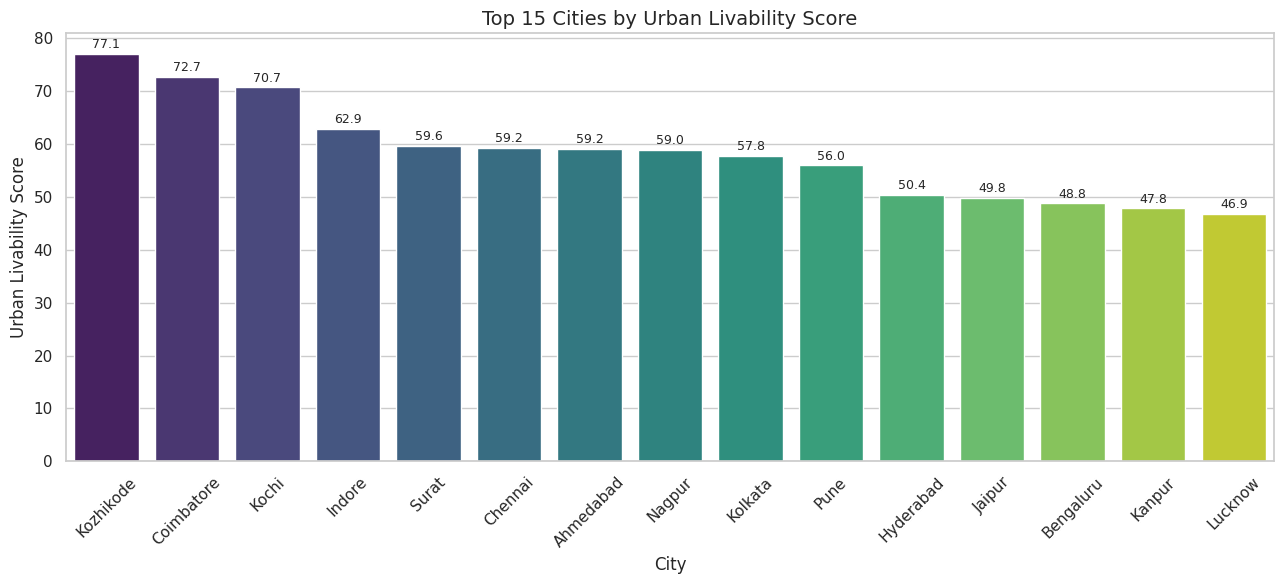

In [ ]:
TOP_N = min(15, len(final_df))
plot_top = final_df.head(TOP_N).copy()

plt.figure(figsize=(13, 6))
ax = sns.barplot(data=plot_top, x="city", y="urban_livability_score", palette="viridis")
ax.set_title(f"Top {TOP_N} Cities by Urban Livability Score", fontsize=14)
ax.set_xlabel("City")
ax.set_ylabel("Urban Livability Score")
ax.tick_params(axis="x", rotation=45)

for i, val in enumerate(plot_top["urban_livability_score"]):
    ax.text(i, val + 0.5, f"{val:.1f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## 13. EDA 2: Radar Chart for Two-City Comparison

In [ ]:
def plot_radar_two_cities(df: pd.DataFrame, city1: str, city2: str, category_cols: list[str]):
    row1 = df[df["city"] == city1]
    row2 = df[df["city"] == city2]

    if row1.empty or row2.empty:
        raise ValueError("One or both cities are not present in the final table.")

    labels = [c.replace("_score", "").title() for c in category_cols]
    vals1 = row1.iloc[0][category_cols].tolist()
    vals2 = row2.iloc[0][category_cols].tolist()

    labels_closed = labels + [labels[0]]
    vals1_closed = vals1 + [vals1[0]]
    vals2_closed = vals2 + [vals2[0]]

    fig = go.Figure()
    fig.add_trace(go.Scatterpolar(r=vals1_closed, theta=labels_closed, fill="toself", name=city1))
    fig.add_trace(go.Scatterpolar(r=vals2_closed, theta=labels_closed, fill="toself", name=city2))

    fig.update_layout(
        title=f"Radar Comparison: {city1} vs {city2}",
        polar=dict(radialaxis=dict(visible=True, range=[0, 100])),
        showlegend=True,
    )
    fig.show()

radar_category_cols = [f"{cat}_score" for cat in CATEGORY_WEIGHTS.keys()]
if len(final_df) >= 2:
    city_a = final_df.iloc[0]["city"]
    city_b = final_df.iloc[1]["city"]
    plot_radar_two_cities(final_df, city_a, city_b, radar_category_cols)
else:
    print("Not enough cities to generate a two-city radar chart.")

## 14. EDA 3: City vs Category Heatmap

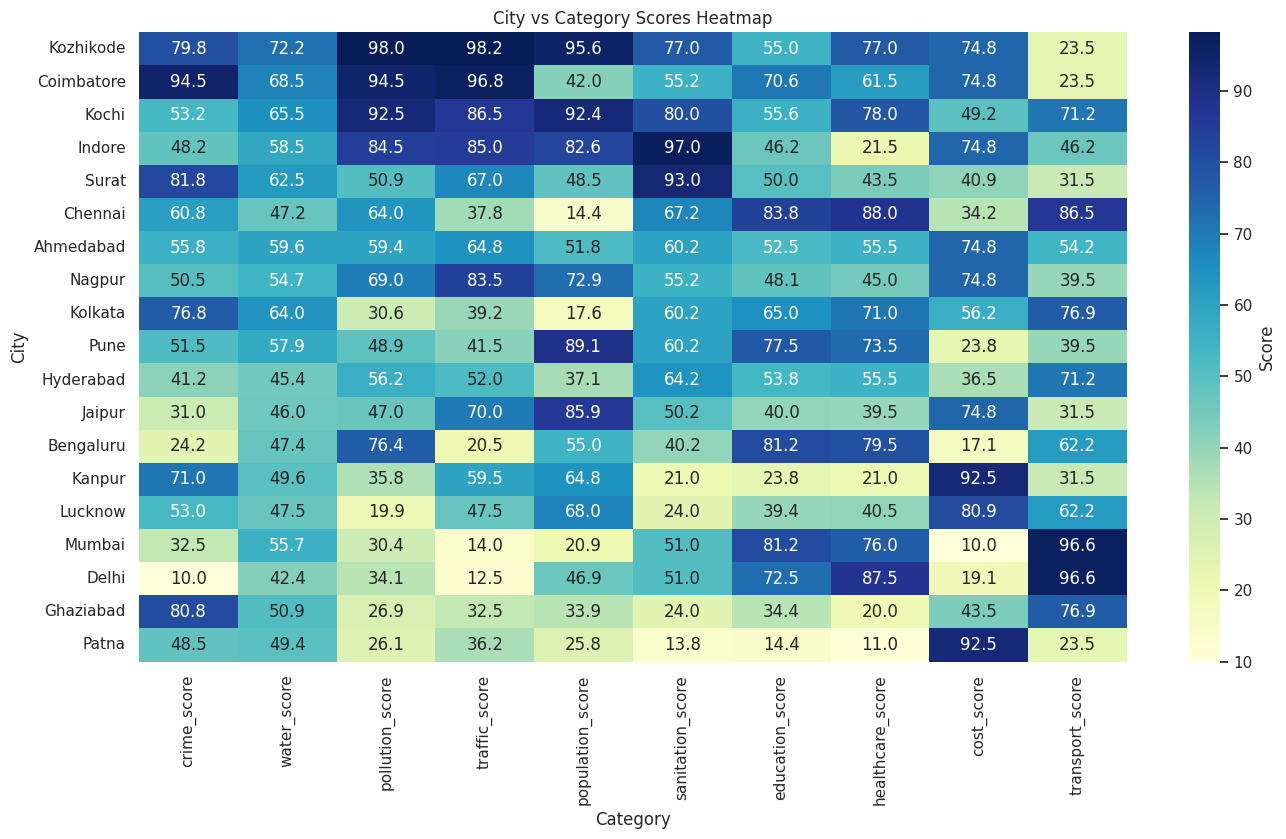

In [ ]:
heatmap_cols = [f"{cat}_score" for cat in CATEGORY_WEIGHTS.keys()]
heatmap_df = final_df[["city"] + heatmap_cols].copy()
heatmap_df = heatmap_df.set_index("city")

# Keep top and bottom cities for readability in presentation.
if len(heatmap_df) > 20:
    top_cities = final_df.head(10)["city"].tolist()
    bottom_cities = final_df.tail(10)["city"].tolist()
    selected_cities = top_cities + [c for c in bottom_cities if c not in top_cities]
    heatmap_df = heatmap_df.loc[selected_cities]

plt.figure(figsize=(14, max(6, 0.45 * len(heatmap_df))))
sns.heatmap(heatmap_df, cmap="YlGnBu", annot=True, fmt=".1f", cbar_kws={"label": "Score"})
plt.title("City vs Category Scores Heatmap")
plt.xlabel("Category")
plt.ylabel("City")
plt.tight_layout()
plt.show()

## 15. EDA 4: Correlation Matrix of Category Scores

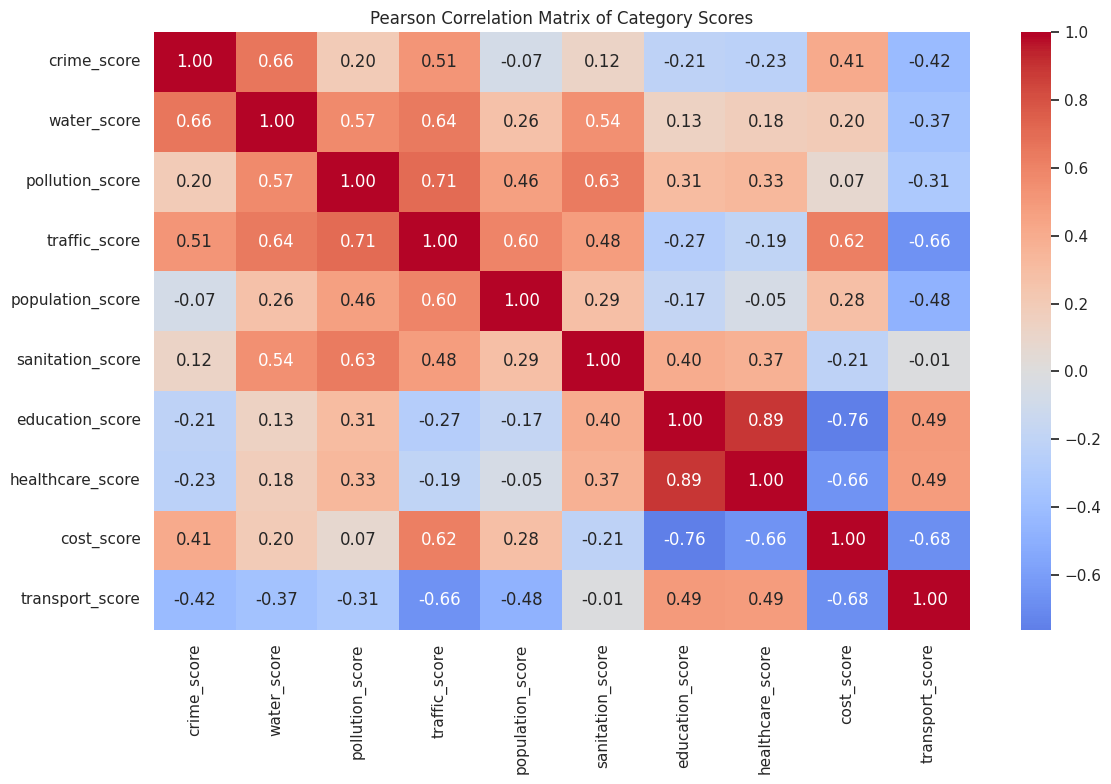

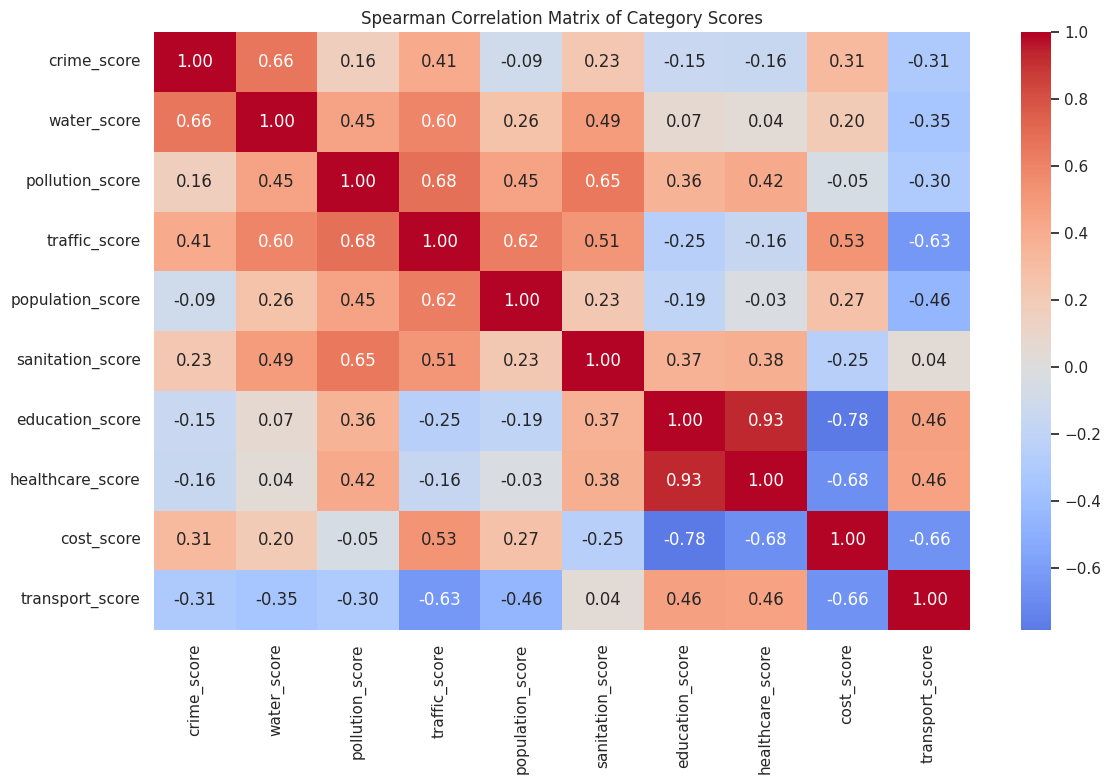

In [ ]:
corr_cols = [f"{cat}_score" for cat in CATEGORY_WEIGHTS.keys()]
pearson_corr = final_df[corr_cols].corr(method="pearson")
spearman_corr = final_df[corr_cols].corr(method="spearman")

plt.figure(figsize=(12, 8))
sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Pearson Correlation Matrix of Category Scores")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Spearman Correlation Matrix of Category Scores")
plt.tight_layout()
plt.show()

## 16. EDA 5: Final Score Distribution and Outlier Check

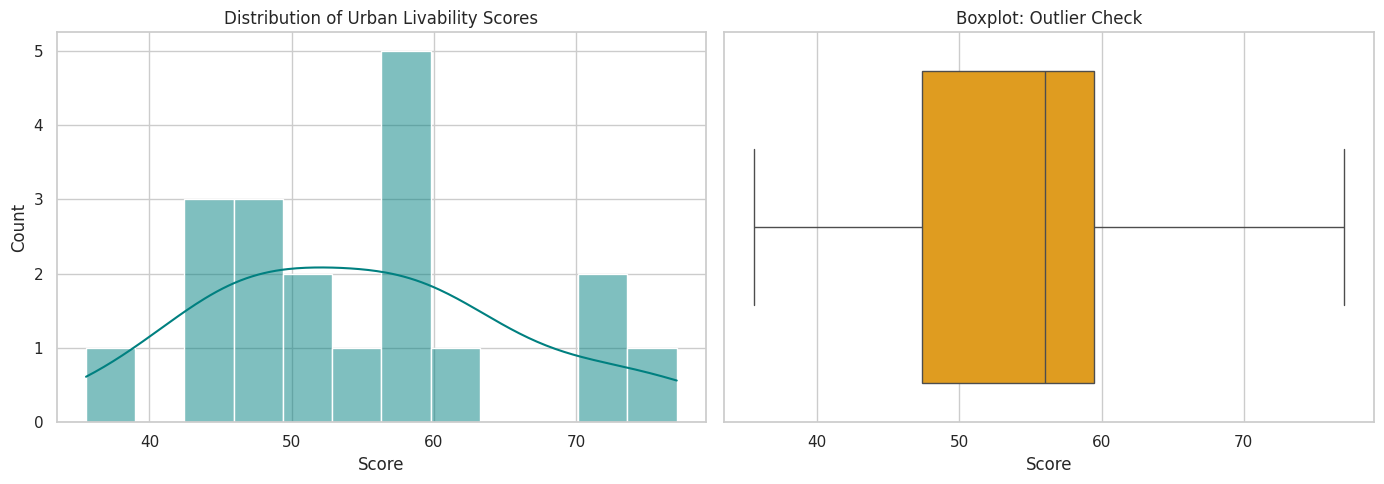

,metric,value
0,mean,55.000000
1,median,56.000000
2,std,10.915947
3,min,35.540000
4,q1,47.350000
5,q3,59.436250
6,max,77.085000


In [ ]:
score_series = final_df["urban_livability_score"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(score_series, kde=True, bins=12, ax=axes[0], color="teal")
axes[0].set_title("Distribution of Urban Livability Scores")
axes[0].set_xlabel("Score")

sns.boxplot(x=score_series, ax=axes[1], color="orange")
axes[1].set_title("Boxplot: Outlier Check")
axes[1].set_xlabel("Score")

plt.tight_layout()
plt.show()

summary_stats = pd.DataFrame(
    {
        "metric": ["mean", "median", "std", "min", "q1", "q3", "max"],
        "value": [
            score_series.mean(),
            score_series.median(),
            score_series.std(),
            score_series.min(),
            score_series.quantile(0.25),
            score_series.quantile(0.75),
            score_series.max(),
        ],
    }
)
display(summary_stats)

## 17. Export Outputs (CSV/Excel) and Save Plots

In [ ]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

ranking_csv = OUTPUT_DIR / f"city_ranking_{timestamp}.csv"
ranking_xlsx = OUTPUT_DIR / f"city_ranking_{timestamp}.xlsx"
rankings_export = ranking_df.copy()
rankings_export.to_csv(ranking_csv, index=False)
rankings_export.to_excel(ranking_xlsx, index=False)

# Export category and normalized sub-parameter tables.
for category, df in category_score_tables.items():
    df.to_csv(OUTPUT_DIR / f"{category}_score_{timestamp}.csv", index=False)

for category, df in normalized_subparam_tables.items():
    df.to_csv(OUTPUT_DIR / f"{category}_normalized_subparams_{timestamp}.csv", index=False)

# Save key static figures (re-render and save cleanly).
plt.figure(figsize=(13, 6))
ax = sns.barplot(data=plot_top, x="city", y="urban_livability_score", palette="viridis")
ax.set_title(f"Top {TOP_N} Cities by Urban Livability Score", fontsize=14)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"top_cities_bar_{timestamp}.png", dpi=300)
plt.close()

plt.figure(figsize=(14, max(6, 0.45 * len(heatmap_df))))
sns.heatmap(heatmap_df, cmap="YlGnBu", annot=True, fmt=".1f", cbar_kws={"label": "Score"})
plt.title("City vs Category Scores Heatmap")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"city_category_heatmap_{timestamp}.png", dpi=300)
plt.close()

plt.figure(figsize=(12, 8))
sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Pearson Correlation Matrix")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"correlation_matrix_{timestamp}.png", dpi=300)
plt.close()

print("Exports completed:")
for p in sorted(OUTPUT_DIR.glob(f"*{timestamp}*")):
    print("-", p.name)

Exports completed:
- city_category_heatmap_20260416_030540.png
- city_ranking_20260416_030540.csv
- city_ranking_20260416_030540.xlsx
- correlation_matrix_20260416_030540.png
- cost_normalized_subparams_20260416_030540.csv
- cost_score_20260416_030540.csv
- crime_normalized_subparams_20260416_030540.csv
- crime_score_20260416_030540.csv
- education_normalized_subparams_20260416_030540.csv
- education_score_20260416_030540.csv
- healthcare_normalized_subparams_20260416_030540.csv
- healthcare_score_20260416_030540.csv
- pollution_normalized_subparams_20260416_030540.csv
- pollution_score_20260416_030540.csv
- population_normalized_subparams_20260416_030540.csv
- population_score_20260416_030540.csv
- sanitation_normalized_subparams_20260416_030540.csv
- sanitation_score_20260416_030540.csv
- top_cities_bar_20260416_030540.png
- traffic_normalized_subparams_20260416_030540.csv
- traffic_score_20260416_030540.csv
- transport_normalized_subparams_20260416_030540.csv
- transport_score_20260